In [1]:
# Cell 1 — Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\rs074\battery-soh-platform\data\battery_features.csv')

# Load models
with open(r'C:\Users\rs074\battery-soh-platform\src\soh_model.pkl', 'rb') as f:
    soh_model = pickle.load(f)
with open(r'C:\Users\rs074\battery-soh-platform\src\rul_model.pkl', 'rb') as f:
    rul_model = pickle.load(f)
with open(r'C:\Users\rs074\battery-soh-platform\src\scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

import json
with open(r'C:\Users\rs074\battery-soh-platform\src\feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print(f'Data loaded ✓ — Shape: {df.shape}')
print(f'Models loaded ✓')
print(f'Features: {len(feature_cols)}')

Data loaded ✓ — Shape: (636, 32)
Models loaded ✓
Features: 25


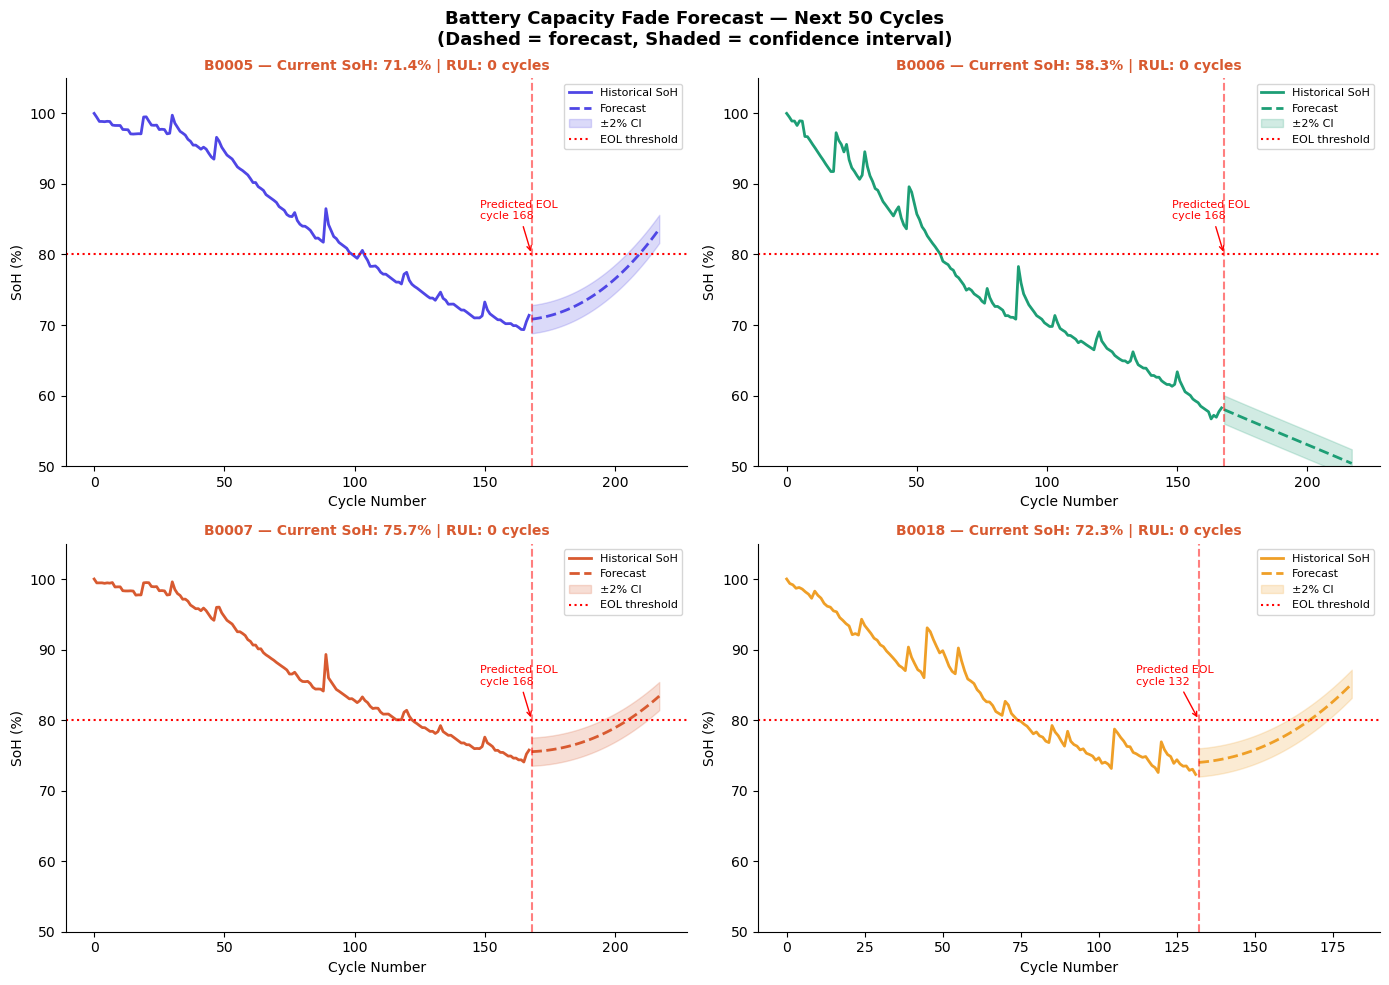

Forecast chart saved ✓

Forecast Summary:
  B0005: Current SoH=71.4% | RUL=0 cycles | SoH in 50 cycles=83.6%
  B0006: Current SoH=58.3% | RUL=0 cycles | SoH in 50 cycles=50.4%
  B0007: Current SoH=75.7% | RUL=0 cycles | SoH in 50 cycles=83.4%
  B0018: Current SoH=72.3% | RUL=0 cycles | SoH in 50 cycles=85.1%


In [2]:
# Cell 2 — Capacity Fade Forecasting
# Forecast next 50 cycles for each battery using polynomial trend fitting

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Battery Capacity Fade Forecast — Next 50 Cycles\n(Dashed = forecast, Shaded = confidence interval)',
             fontsize=13, fontweight='bold')

colors = {'B0005': '#4F46E5', 'B0006': '#1D9E75',
          'B0007': '#D85A30', 'B0018': '#EF9F27'}

forecast_results = {}

for ax, battery in zip(axes.flatten(), ['B0005', 'B0006', 'B0007', 'B0018']):
    bdf = df[df['Battery'] == battery].copy()
    cycles = bdf['Cycle_Index'].values
    soh    = bdf['SoH'].values

    # Fit polynomial trend
    z = np.polyfit(cycles, soh, deg=3)
    p = np.poly1d(z)

    # Forecast next 50 cycles
    last_cycle   = cycles[-1]
    future_cycles = np.arange(last_cycle + 1, last_cycle + 51)
    forecast_soh  = p(future_cycles)
    forecast_soh  = np.clip(forecast_soh, 0, 100)

    # Confidence interval (±2% based on model MAE)
    ci_upper = np.clip(forecast_soh + 2.0, 0, 100)
    ci_lower = np.clip(forecast_soh - 2.0, 0, 100)

    # Find predicted EOL
    eol_forecast = future_cycles[forecast_soh < 80]
    eol_cycle = eol_forecast[0] if len(eol_forecast) > 0 else None

    # Current status
    current_soh = soh[-1]
    current_rul = bdf['RUL'].values[-1]

    forecast_results[battery] = {
        'current_soh': current_soh,
        'current_rul': current_rul,
        'eol_cycle'  : eol_cycle,
        'forecast_50': forecast_soh[-1]
    }

    # Plot
    ax.plot(cycles, soh, color=colors[battery], linewidth=2, label='Historical SoH')
    ax.plot(future_cycles, forecast_soh, color=colors[battery],
            linewidth=2, linestyle='--', label='Forecast')
    ax.fill_between(future_cycles, ci_lower, ci_upper,
                    alpha=0.2, color=colors[battery], label='±2% CI')
    ax.axhline(y=80, color='red', linestyle=':', linewidth=1.5, label='EOL threshold')

    if eol_cycle:
        ax.axvline(x=eol_cycle, color='red', linestyle='--', alpha=0.5)
        ax.annotate(f'Predicted EOL\ncycle {eol_cycle}',
                   xy=(eol_cycle, 80),
                   xytext=(eol_cycle - 20, 85),
                   fontsize=8, color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))

    status_color = '#D85A30' if current_soh < 80 else '#EF9F27' if current_soh < 90 else '#1D9E75'
    ax.set_title(f'{battery} — Current SoH: {current_soh:.1f}% | RUL: {current_rul} cycles',
                 fontsize=10, color=status_color, fontweight='bold')
    ax.set_xlabel('Cycle Number')
    ax.set_ylabel('SoH (%)')
    ax.set_ylim(50, 105)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\capacity_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Forecast chart saved ✓')
print('\nForecast Summary:')
for battery, result in forecast_results.items():
    print(f'  {battery}: Current SoH={result["current_soh"]:.1f}% | '
          f'RUL={result["current_rul"]} cycles | '
          f'SoH in 50 cycles={result["forecast_50"]:.1f}%')

In [3]:
# Cell 3 — Battery Alert System & Maintenance Recommendations
print('='*60)
print('   BATTERY HEALTH ALERT SYSTEM')
print('   (Simulating real-time BMS monitoring)')
print('='*60)

def get_alert(soh, rul, battery_name):
    if soh >= 90:
        tier = 'GREEN'
        icon = '✅'
        action = 'No action needed. Continue normal operation.'
        urgency = 'Low'
    elif soh >= 80:
        tier = 'YELLOW'
        icon = '⚠️'
        action = 'Schedule inspection within 30 days. Monitor closely.'
        urgency = 'Medium'
    elif soh >= 70:
        tier = 'ORANGE'
        icon = '🔶'
        action = 'Immediate inspection required. Plan replacement within 2 weeks.'
        urgency = 'High'
    else:
        tier = 'RED'
        icon = '🔴'
        action = 'CRITICAL: Replace battery immediately. Risk of failure.'
        urgency = 'Critical'
    return tier, icon, action, urgency

# Simulate monitoring at different cycle points
monitor_cycles = [0, 30, 60, 90, 120, 150]

for battery in ['B0005', 'B0006', 'B0007', 'B0018']:
    bdf = df[df['Battery'] == battery]
    print(f'\n📊 {battery} — Health Timeline:')
    print(f'  {"Cycle":>6} | {"SoH":>8} | {"RUL":>6} | {"Status":>8} | Action')
    print(f'  {"-"*70}')
    
    for cycle in monitor_cycles:
        row = bdf[bdf['Cycle_Index'] == cycle]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        tier, icon, action, urgency = get_alert(row['SoH'], row['RUL'], battery)
        print(f'  {cycle:>6} | {row["SoH"]:>7.1f}% | {int(row["RUL"]):>6} | '
              f'{icon} {tier:>6} | {action[:45]}')

print(f'\n{"="*60}')

# India-specific alert additions
print('\n🇮🇳 INDIA-SPECIFIC ALERTS:')
print('-'*60)
india_alerts = [
    ('Summer Heat (Apr-Jun)', 'Thermal stress ×1.4 — Reduce fast charging'),
    ('Monsoon humidity',      'Check sealing integrity — Moisture risk'),
    ('Dust exposure',         'Clean cooling vents monthly'),
    ('Load shedding cycles',  'Irregular charging patterns detected — Monitor'),
    ('High ambient temp',     'Expected RUL reduced by 15-20% vs lab conditions'),
]
for alert, action in india_alerts:
    print(f'  ⚠️  {alert:30s} → {action}')

   BATTERY HEALTH ALERT SYSTEM
   (Simulating real-time BMS monitoring)

📊 B0005 — Health Timeline:
   Cycle |      SoH |    RUL |   Status | Action
  ----------------------------------------------------------------------
       0 |   100.0% |    100 | ✅  GREEN | No action needed. Continue normal operation.
      30 |    99.7% |     70 | ✅  GREEN | No action needed. Continue normal operation.
      60 |    90.8% |     40 | ✅  GREEN | No action needed. Continue normal operation.
      90 |    84.2% |     10 | ⚠️ YELLOW | Schedule inspection within 30 days. Monitor c
     120 |    77.5% |      0 | 🔶 ORANGE | Immediate inspection required. Plan replaceme
     150 |    73.3% |      0 | 🔶 ORANGE | Immediate inspection required. Plan replaceme

📊 B0006 — Health Timeline:
   Cycle |      SoH |    RUL |   Status | Action
  ----------------------------------------------------------------------
       0 |   100.0% |     60 | ✅  GREEN | No action needed. Continue normal operation.
      30 |    9

   OPTIMAL CHARGING STRATEGY ANALYSIS


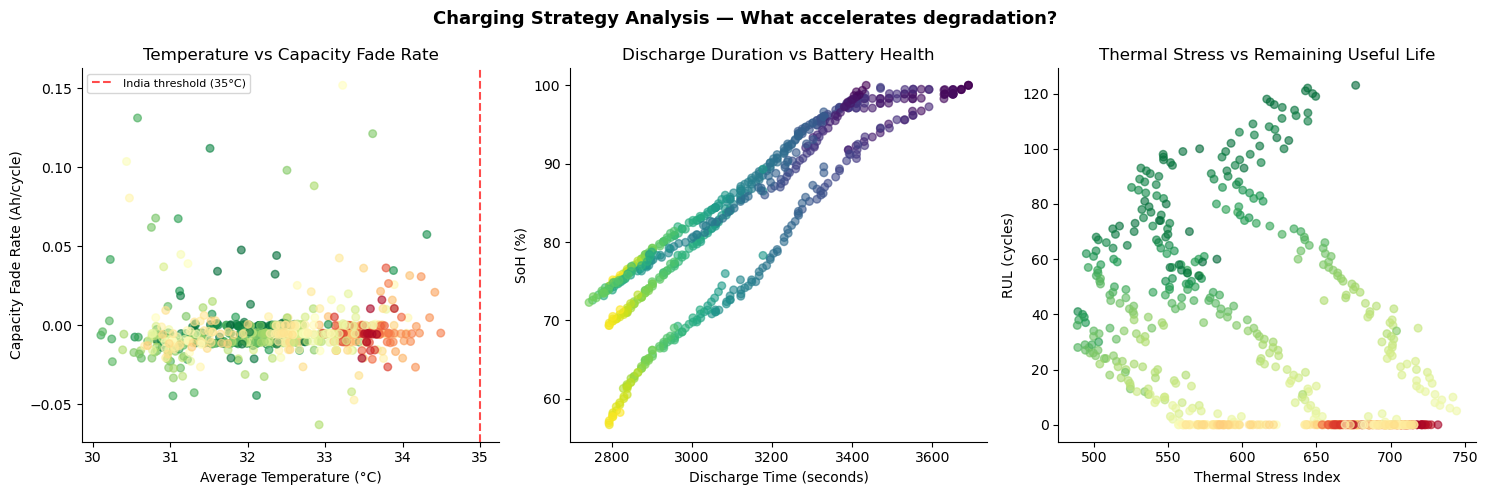

Chart saved ✓

   CHARGING RECOMMENDATIONS

  [1] Keep temperature below 35°C
      → Avg temp in dataset: 32.3°C. Indian summer adds ~10°C → accelerates fade by ~20%

  [2] Avoid deep discharge
      → Min voltage avg: 2.388V. Staying above 2.8V preserves cell chemistry

  [3] Slow charging preferred
      → High current increases temp rise. Avg temp rise: 15.6°C per cycle

  [4] Schedule replacement at 80% SoH
      → Industry standard EOL threshold. Operating below 80% risks sudden failure

  [5] India monsoon protocol
      → Humidity above 80% degrades electrolyte. Seal inspection every 3 months during Jun-Sep

   WEEK 4 COMPLETE

  Deliverables:
  → Capacity fade forecast (next 50 cycles)
  → 4-tier alert system (Green/Yellow/Orange/Red)
  → India-specific alerts (heat, humidity, dust)
  → Charging strategy recommendations
  → 2 charts saved to /reports

  Next → Week 5: Streamlit App + Power BI Dashboard



In [4]:
# Cell 4 — Charging Strategy Analysis & Recommendations
print('='*60)
print('   OPTIMAL CHARGING STRATEGY ANALYSIS')
print('='*60)

# Analyse relationship between temperature and degradation rate
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Charging Strategy Analysis — What accelerates degradation?',
             fontsize=13, fontweight='bold')

# Plot 1 — Temperature vs Capacity Fade Rate
axes[0].scatter(df['avg_temp'], df['capacity_fade_rate'],
                c=df['SoH'], cmap='RdYlGn', alpha=0.6, s=30)
axes[0].set_xlabel('Average Temperature (°C)')
axes[0].set_ylabel('Capacity Fade Rate (Ah/cycle)')
axes[0].set_title('Temperature vs Capacity Fade Rate')
axes[0].axvline(x=35, color='red', linestyle='--', alpha=0.7, label='India threshold (35°C)')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Plot 2 — Discharge time vs SoH
axes[1].scatter(df['discharge_time'], df['SoH'],
                c=df['Cycle_Index'], cmap='viridis', alpha=0.6, s=30)
axes[1].set_xlabel('Discharge Time (seconds)')
axes[1].set_ylabel('SoH (%)')
axes[1].set_title('Discharge Duration vs Battery Health')
axes[1].spines[['top', 'right']].set_visible(False)

# Plot 3 — Thermal stress vs RUL
axes[2].scatter(df['thermal_stress'], df['RUL'],
                c=df['SoH'], cmap='RdYlGn', alpha=0.6, s=30)
axes[2].set_xlabel('Thermal Stress Index')
axes[2].set_ylabel('RUL (cycles)')
axes[2].set_title('Thermal Stress vs Remaining Useful Life')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\charging_strategy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

# Recommendations
print('\n' + '='*60)
print('   CHARGING RECOMMENDATIONS')
print('='*60)

recommendations = [
    ('Keep temperature below 35°C',
     f'Avg temp in dataset: {df["avg_temp"].mean():.1f}°C. '
     f'Indian summer adds ~10°C → accelerates fade by ~20%'),
    ('Avoid deep discharge',
     f'Min voltage avg: {df["min_voltage"].mean():.3f}V. '
     f'Staying above 2.8V preserves cell chemistry'),
    ('Slow charging preferred',
     f'High current increases temp rise. '
     f'Avg temp rise: {df["temp_rise"].mean():.1f}°C per cycle'),
    ('Schedule replacement at 80% SoH',
     f'Industry standard EOL threshold. '
     f'Operating below 80% risks sudden failure'),
    ('India monsoon protocol',
     f'Humidity above 80% degrades electrolyte. '
     f'Seal inspection every 3 months during Jun-Sep'),
]

for i, (rec, detail) in enumerate(recommendations, 1):
    print(f'\n  [{i}] {rec}')
    print(f'      → {detail}')

print(f'\n{"="*60}')
print('   WEEK 4 COMPLETE')
print(f'{"="*60}')
print('''
  Deliverables:
  → Capacity fade forecast (next 50 cycles)
  → 4-tier alert system (Green/Yellow/Orange/Red)
  → India-specific alerts (heat, humidity, dust)
  → Charging strategy recommendations
  → 2 charts saved to /reports

  Next → Week 5: Streamlit App + Power BI Dashboard
''')